### ИМПОРТ БИБЛИОТЕК

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.linalg import eigh
from scipy.linalg import eig
from scipy.interpolate import CubicSpline
import math

### ГЕОМЕТРИЯ И МАТЕРИАЛ

In [2]:
Ls = 1.8                   # Длина вала, м
d = 0.04                   # Диаметр вала, м
D = 0.3                    # Диаметр диска, м
h = 0.05                   # Ширина диска, м
z_disk = Ls * 0.2          # Положение диска вдоль вала, м
ro = 7800                  # Плотность материала, кг/м³
E = 2.1e11                 # Модуль Юнга, Па

# Геометрические характеристики сечения
A = np.pi * d**2 / 4       # Площадь сечения, м²
Ix = np.pi * d**4 / 64     # Момент инерции относительно X, м⁴
Iy = Ix                    # Момент инерции относительно Y, м⁴
Ip = np.pi * d**4 / 32     # Полярный момент инерции, м⁴

### ПАРАМЕТРЫ КОНЕЧНО-ЭЛЕМЕНТНОЙ СЕТКИ

In [3]:
n_elems = 10               # Количество конечных элементов
n_nodes = n_elems + 1      # Количество узлов
L = Ls / n_elems           # Длина одного элемента, м

### Проверка соотношения L/d

In [4]:
ratio = L / d
print("=" * 50)
print(f"ПАРАМЕТРЫ МОДЕЛИ")
print("=" * 50)
print(f"L/d = {ratio:.2f} (рекомендуемый диапазон: 4-5)")

ПАРАМЕТРЫ МОДЕЛИ
L/d = 4.50 (рекомендуемый диапазон: 4-5)


### МАТРИЦА ЖЕСТКОСТИ КОНЕЧНОГО ЭЛЕМЕНТА

In [5]:
def element_stiffness_matrix(E: float, Ix: float, Iy: float, L: float) -> np.ndarray:
    factor = E / L**3
    
    # Изгиб в плоскости YZ (вокруг оси X)
    k_yz = factor * Ix * np.array([
        [12,   -6*L,  -12,   -6*L],
        [-6*L,  4*L**2,  6*L,  2*L**2],
        [-12,    6*L,   12,    6*L],
        [-6*L,  2*L**2,  6*L,  4*L**2]
    ])
    
    # Изгиб в плоскости XZ (вокруг оси Y)
    k_xz = factor * Iy * np.array([
        [12,    6*L,  -12,    6*L],
        [6*L,   4*L**2, -6*L,  2*L**2],
        [-12,   -6*L,   12,   -6*L],
        [6*L,   2*L**2, -6*L,  4*L**2]
    ])
    
    K = np.zeros((8, 8))
    yz_dofs = [0, 3, 4, 7]
    xz_dofs = [1, 2, 5, 6]
    
    K[np.ix_(yz_dofs, yz_dofs)] = k_yz
    K[np.ix_(xz_dofs, xz_dofs)] = k_xz
    
    return K

### СБОРКА ГЛОБАЛЬНОЙ МАТРИЦЫ ЖЕСТКОСТИ

In [6]:
def assemble_global_stiffness(K_element: np.ndarray, 
                              node1_idx: int, 
                              node2_idx: int, 
                              K_global: lil_matrix) -> lil_matrix:
    start_idx1 = 4 * node1_idx
    start_idx2 = 4 * node2_idx
    indices = np.array([
        start_idx1, start_idx1 + 1, start_idx1 + 2, start_idx1 + 3,
        start_idx2, start_idx2 + 1, start_idx2 + 2, start_idx2 + 3
    ])
    
    rows, cols = np.meshgrid(indices, indices, indexing='ij')
    K_global[rows, cols] += K_element
    
    return K_global


# Вычисление матрицы жесткости элемента (одинакова для всех элементов)
K_element = element_stiffness_matrix(E, Ix, Iy, L)

# Инициализация и сборка глобальной матрицы жесткости
n_dofs = 4 * n_nodes
K_global = lil_matrix((n_dofs, n_dofs))

for e in range(n_elems):
    node1, node2 = e, e + 1
    K_global = assemble_global_stiffness(K_element, node1, node2, K_global)

K = K_global.toarray()
if hasattr(K_global, "toarray"):
    K_global = K_global.toarray()

print(f"\nГлобальная матрица жесткости: {K.shape}")
print(f"Макс. отклонение от симметрии: {np.max(np.abs(K - K.T)):.2e}")


Глобальная матрица жесткости: (44, 44)
Макс. отклонение от симметрии: 0.00e+00


### МАТРИЦА МАСС КОНЕЧНОГО ЭЛЕМЕНТА

In [7]:
# Масса и момент инерции диска
Md = ro * h * np.pi * D**2 / 4               # Масса диска, кг
Jd = Md * D**2 / 16 + Md * h**2 / 12         # Момент инерции диска, кг·м²

def element_mass_matrix(ro: float, A: float, L: float) -> np.ndarray:
    factor = ro * A * L / 420
    
    M_bend = factor * np.array([
        [156,   22*L,   54,   -13*L],
        [22*L,  4*L**2, 13*L, -3*L**2],
        [54,    13*L,   156,  -22*L],
        [-13*L, -3*L**2, -22*L, 4*L**2]
    ])
    
    M = np.zeros((8, 8))
    xz_dofs = [0, 2, 4, 6]
    yz_dofs = [1, 3, 5, 7]
    
    M[np.ix_(yz_dofs, yz_dofs)] = M_bend
    M[np.ix_(xz_dofs, xz_dofs)] = M_bend
    
    return M

### СБОРКА ГЛОБАЛЬНОЙ МАТРИЦЫ МАСС

In [8]:
def assemble_global_mass(M_element: np.ndarray, 
                         node1_idx: int, 
                         node2_idx: int, 
                         M_global: lil_matrix) -> lil_matrix:
    
    start_idx1 = 4 * node1_idx
    start_idx2 = 4 * node2_idx
    indices = np.array([
        start_idx1, start_idx1 + 1, start_idx1 + 2, start_idx1 + 3,
        start_idx2, start_idx2 + 1, start_idx2 + 2, start_idx2 + 3
    ])
    
    rows, cols = np.meshgrid(indices, indices, indexing='ij')
    M_global[rows, cols] += M_element
    
    return M_global


M_element = element_mass_matrix(ro, A, L)
M_global = lil_matrix((n_dofs, n_dofs))

for e in range(n_elems):
    node1, node2 = e, e + 1
    M_global = assemble_global_mass(M_element, node1, node2, M_global)

# Добавление массы диска
disk_node = 2
dof_start = 4 * disk_node
M_global[dof_start, dof_start] += Md          # Ux
M_global[dof_start + 1, dof_start + 1] += Md  # Uy
M_global[dof_start + 2, dof_start + 2] += Jd  # Rx
M_global[dof_start + 3, dof_start + 3] += Jd  # Ry

M = M_global.toarray()
if hasattr(M_global, "toarray"):
    M_global = M_global.toarray()

print(f"Глобальная матрица масс: {M.shape}")
print(f"Масса диска: {Md:.2f} кг, Момент инерции: {Jd:.4f} кг·м²")

Глобальная матрица масс: (44, 44)
Масса диска: 27.57 кг, Момент инерции: 0.1608 кг·м²


### ПАРАМЕТРЫ ДИСБАЛАНСА И СИЛЫ НАГРУЗКИ

In [9]:
e = 0.1                     # Эксцентриситет, м
rpm = 3000                  # Частота вращения, об/мин
rot_freq_hz = rpm / 60       # Частота вращения, Гц
Omega = 2 * np.pi * rot_freq_hz  # Угловая скорость, рад/с
gamma = 0                   # Фаза дисбаланса, рад
g = 9.80665                 # Ускорение свободного падения, м/с²

def imbalance_force_vector(n_nodes: int, disk_node_idx: int, M_d: float, 
                          e: float, Omega: float, gamma: float = 0.0, 
                          g: float = 9.80665) -> np.ndarray:
    N = n_nodes * 4
    F = np.zeros((N, 1))
    
    Fx = M_d * e * Omega**2 * np.cos(gamma)
    Fy = M_d * e * Omega**2 * np.sin(gamma) - M_d * g
    
    base_idx = 4 * disk_node_idx
    F[base_idx, 0] = Fx      # Ux компонента
    F[base_idx + 1, 0] = Fy  # Uy компонента
    
    return F


F_imbalance = imbalance_force_vector(n_nodes, disk_node, Md, e, Omega, gamma, g)
print(f"\nСила дисбаланса: X={F_imbalance[4*disk_node, 0]:.2f} Н, Y={F_imbalance[4*disk_node + 1, 0]:.2f} Н")


Сила дисбаланса: X=272080.08 Н, Y=-270.34 Н


### ГИРОСКОПИЧЕСКАЯ МАТРИЦА

In [10]:
Jzz = Md * D**2 / 8

def build_gyroscopic_matrix(n_nodes: int, disks: list) -> np.ndarray:
    ndof = n_nodes * 4
    G0 = np.zeros((ndof, ndof))
    
    for disk in disks:
        node = disk['node']
        Jp = disk['Jp']
        
        rx = 4 * node + 2  # Rx
        ry = 4 * node + 3  # Ry
        
        G0[rx, ry] += Jp
        G0[ry, rx] -= Jp
    
    return G0


disks = [{'node': 2, 'Jp': Jzz}]
G0 = build_gyroscopic_matrix(n_nodes, disks)
G = Omega * G0

print(f"\nГироскопическая матрица: {G.shape}")
print(f"Макс. отклонение от кососимметрии: {np.max(np.abs(G + G.T)):.2e}")


Гироскопическая матрица: (44, 44)
Макс. отклонение от кососимметрии: 0.00e+00


### МАТРИЦА ДЕМПФИРОВАНИЯ В ПОДШИПНИКАХ

In [11]:
def build_bearing_damping_matrix(n_nodes: int, c_b: float) -> np.ndarray:
    ndof = n_nodes * 4
    D_b = np.zeros((ndof, ndof))
    
    # Первый узел (узел 0)
    D_b[0, 0] = c_b   # Ux
    D_b[1, 1] = c_b   # Uy
    
    # Последний узел
    last_node = n_nodes - 1
    D_b[4*last_node, 4*last_node] = c_b      # Ux
    D_b[4*last_node + 1, 4*last_node + 1] = c_b  # Uy
    
    return D_b

c_b = 1e3  # Н·с/м
D_b = build_bearing_damping_matrix(n_nodes, c_b)
print(f"\nМатрица демпфирования: {D_b.shape}")


Матрица демпфирования: (44, 44)


### ГРАНИЧНЫЕ УСЛОВИЯ И РЕДУКЦИЯ МАТРИЦ

In [12]:
def build_bearing_stiffness_matrix(n_nodes: int, k_bx: float, k_by: float, bearing_nodes: list) -> np.ndarray:
    ndof = n_nodes * 4
    Kb = np.zeros((ndof, ndof))

    for node in bearing_nodes:
        ux = 4 * node
        uy = ux + 1
        Kb[ux, ux] += k_bx
        Kb[uy, uy] += k_by

    return Kb
    
bearing_nodes = [0, n_nodes - 1]
k_bx = 5e7   
k_by = 5e7

K_b = build_bearing_stiffness_matrix(n_nodes, k_bx, k_by, bearing_nodes)
K_global = K_global + K_b

In [13]:
fixed_dofs = np.array([], dtype=int)
n_dofs = 4 * n_nodes
free_dofs = np.arange(n_dofs)

# Берём подматрицы уже из плотных массивов
Kf = K_global[np.ix_(free_dofs, free_dofs)]
Mf = M_global[np.ix_(free_dofs, free_dofs)]

print(f"Размерность Kf: {Kf.shape}, Mf: {Mf.shape}")

Размерность Kf: (44, 44), Mf: (44, 44)


### РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ И ПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ


РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ
Всего собственных частот: 44
Уникальных собственных частот: 22

ПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ
----------------------------------------


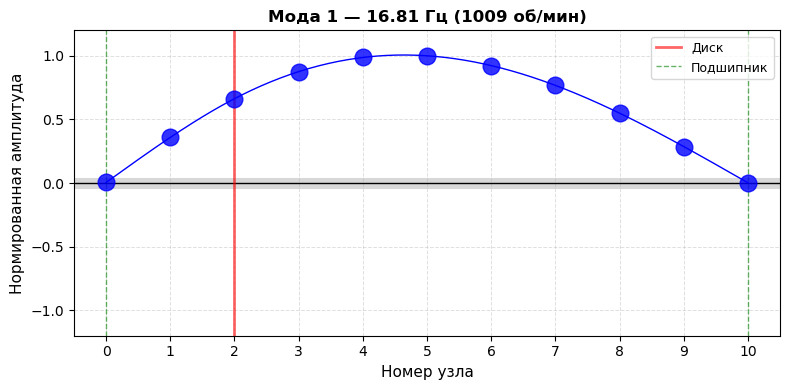

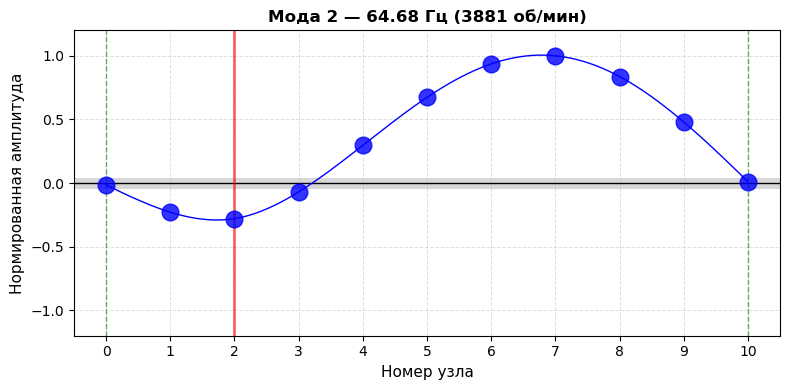

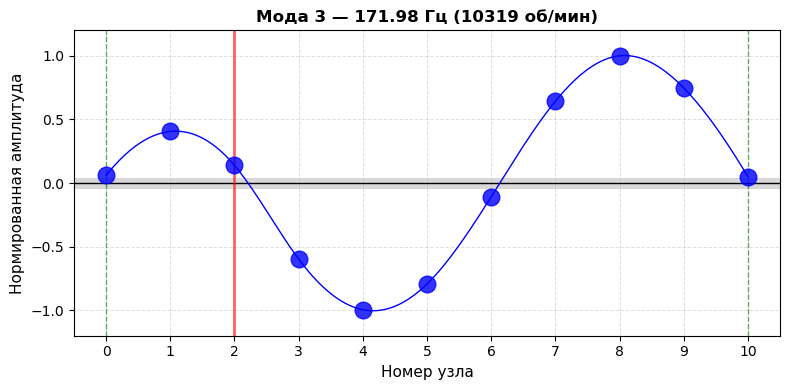

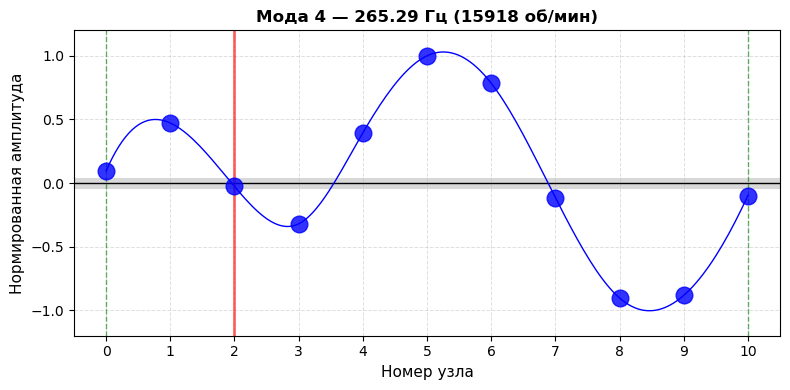

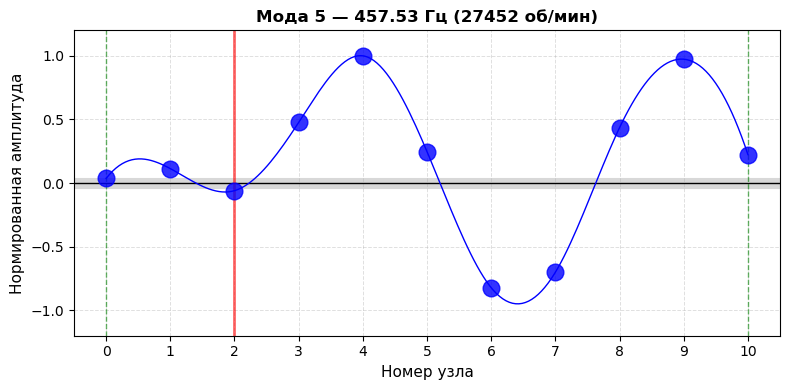

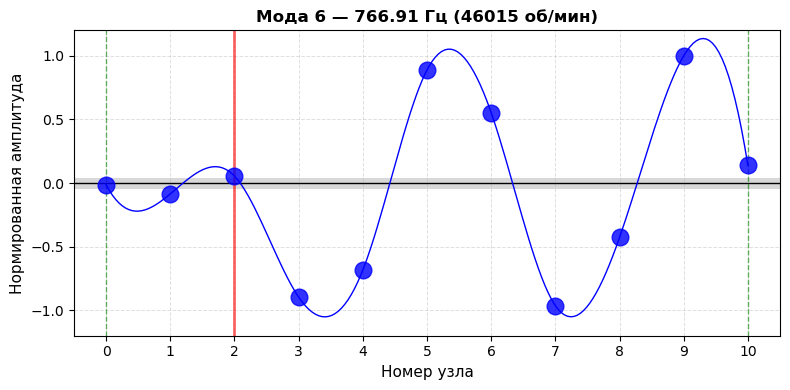

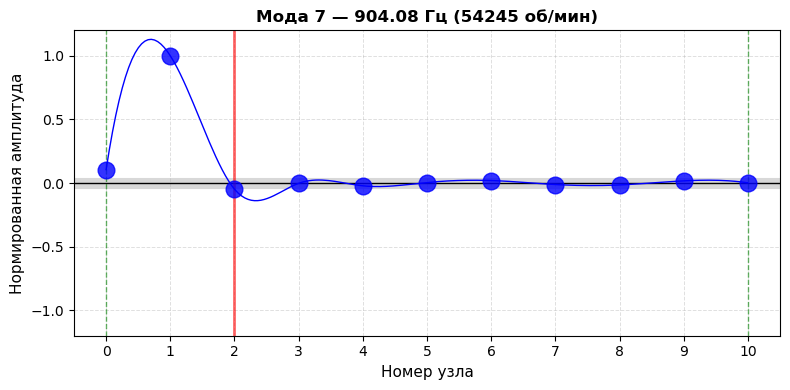

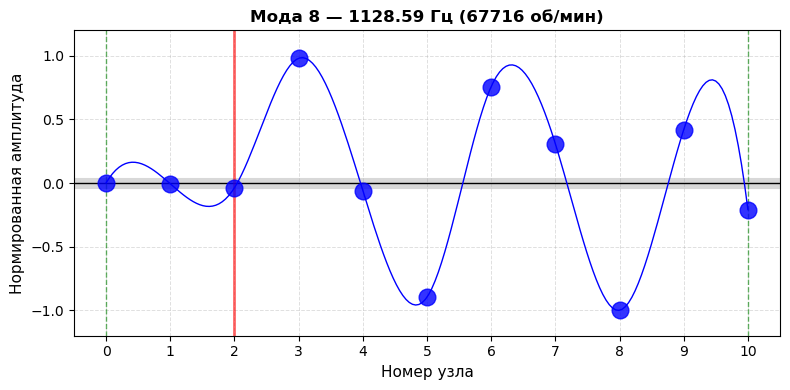

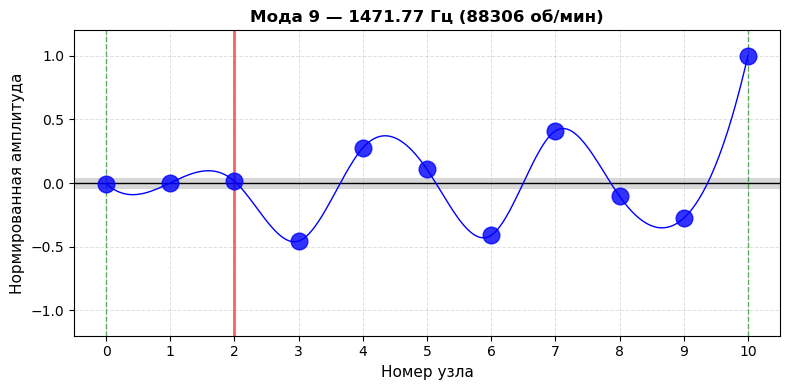

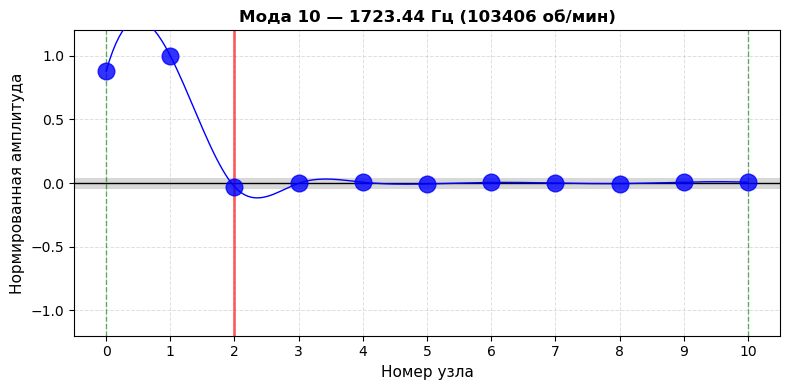

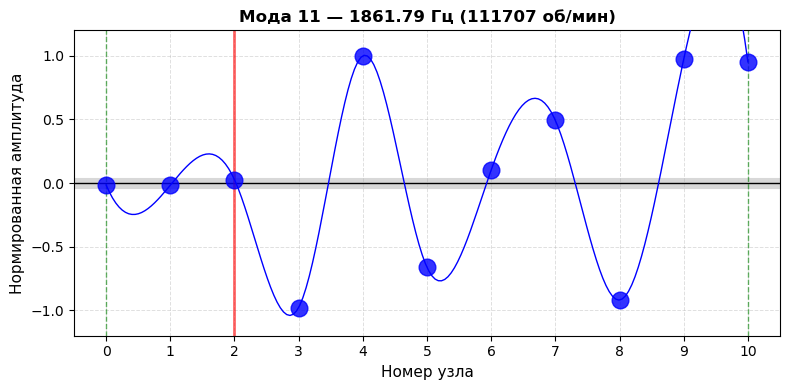

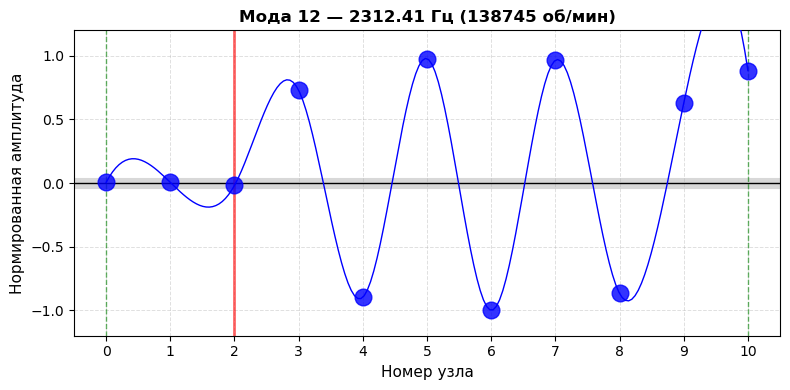

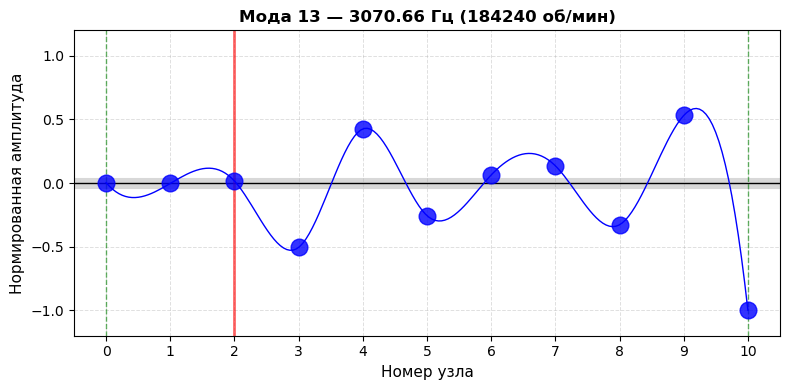

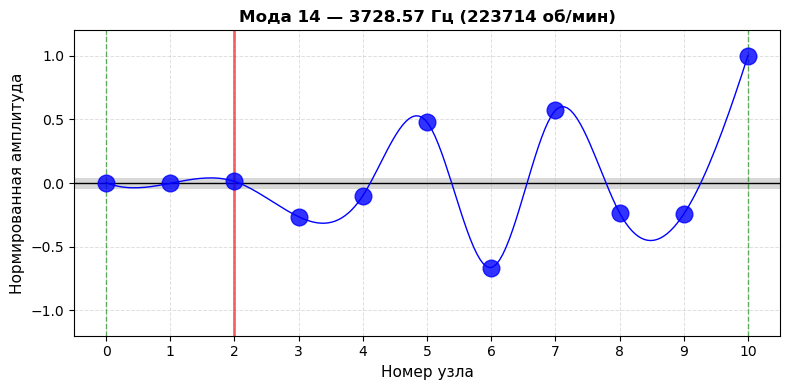

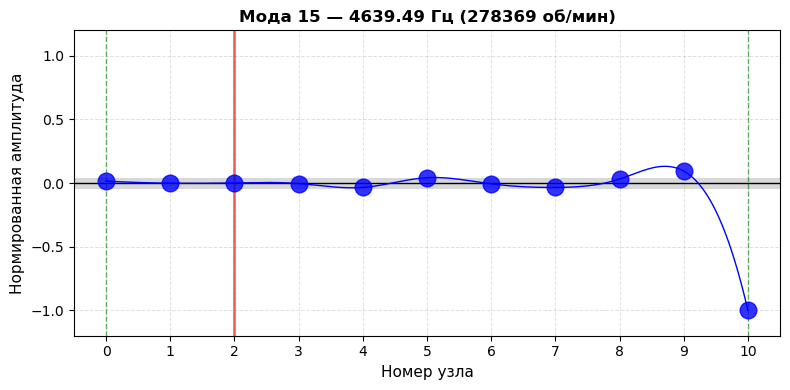

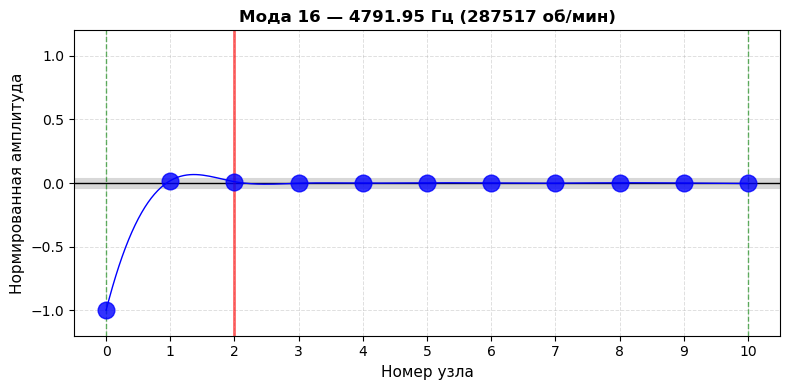

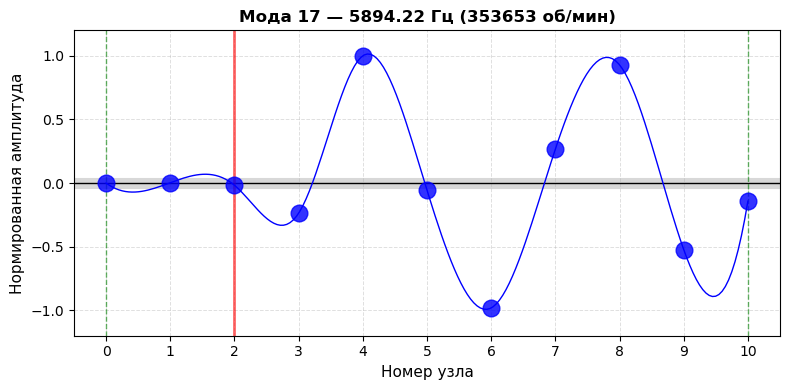

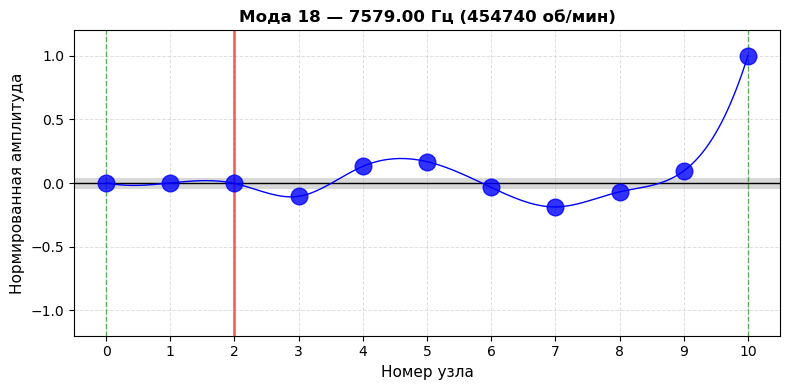

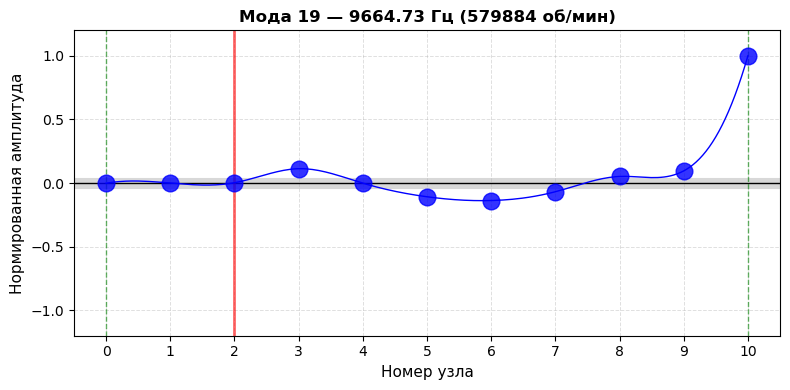

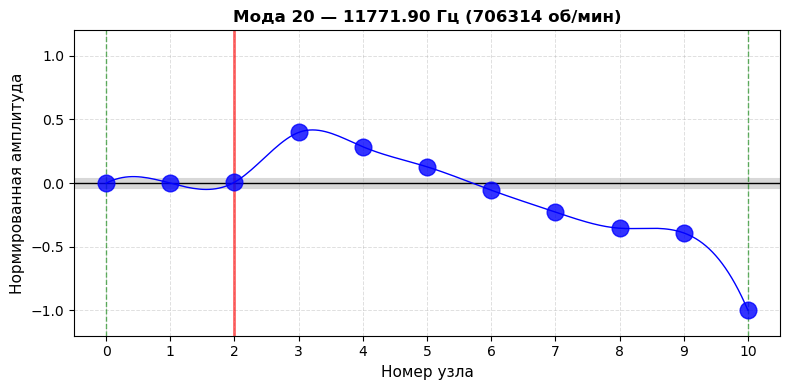

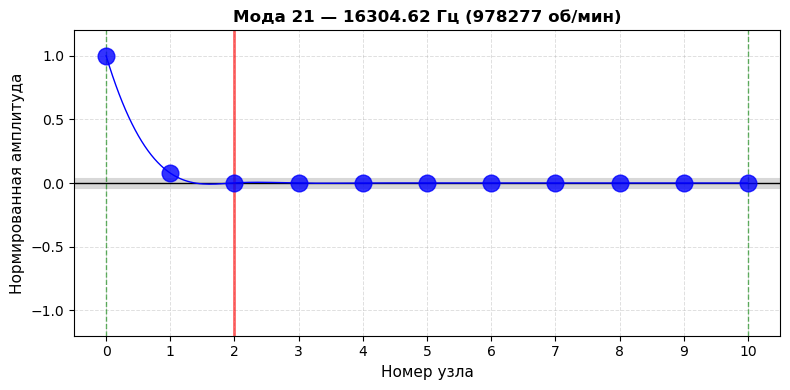

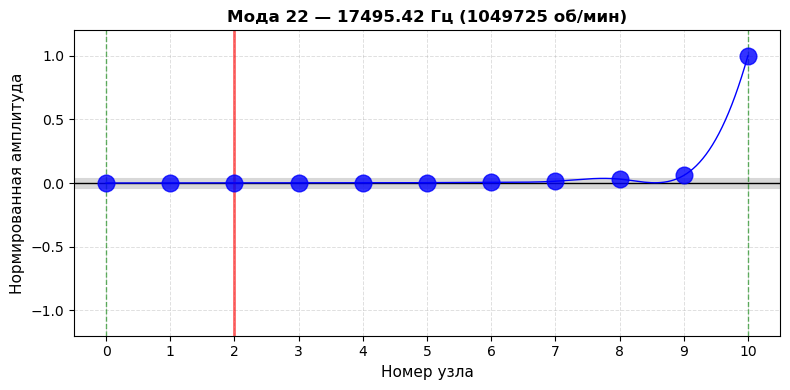


СОБСТВЕННЫЕ ЧАСТОТЫ:
------------------------------------------------------------
 Мода  Частота, Гц  Частота, об/мин
------------------------------------------------------------
    1         16.81          1008.82
    2         64.68          3880.81
    3        171.98         10318.87
    4        265.29         15917.57
    5        457.53         27451.54
    6        766.91         46014.84
    7        904.08         54244.68
    8       1128.59         67715.57
    9       1471.77         88306.30
   10       1723.44        103406.25
   11       1861.79        111707.26
   12       2312.41        138744.68
  ... и еще 10 мод
Получено 44 собственных частот


In [22]:
def solve_eigen_and_plot(Kf: np.ndarray, Mf: np.ndarray, 
                         free_dofs: np.ndarray, fixed_dofs: np.ndarray,
                         n_nodes: int, Ls: float = 1.8, 
                         normalize: bool = True, scale_rot: float = 0.1,
                         save_plots: bool = False, out_dir: str = "mode_plots",
                         disk_nodes: list = None, bearing_nodes: list = None) -> tuple:
    if disk_nodes is None:
        disk_nodes = [2]
    if bearing_nodes is None:
        bearing_nodes = [0, n_nodes-1]
    
    # Проверки размерностей
    ndof = n_nodes * 4
    if Kf.shape != Mf.shape:
        raise ValueError("Матрицы Kf и Mf должны иметь одинаковую размерность")
    
    print("\n" + "=" * 60)
    print("РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ")
    print("=" * 60)
    
    # Решение обобщенной задачи на собственные значения
    eigvals, eigvecs = eigh(Kf, Mf)
    
    # Обработка собственных значений
    eigvals = np.real(eigvals)
    eigvals[eigvals < 0] = 0.0
    freqs_hz = np.sqrt(eigvals) / (2.0 * np.pi)
    freqs_rpm = freqs_hz * 60
    
    # Сортировка по частоте
    sorted_idx = np.argsort(freqs_hz)
    freqs_hz = freqs_hz[sorted_idx]
    eigvecs = eigvecs[:, sorted_idx]
    
    # Выбор уникальных мод (каждая вторая)
    unique_idx = np.arange(0, len(freqs_hz), 2)
    n_unique = len(unique_idx)
    freqs_unique = freqs_hz[unique_idx]
    rpm_unique = freqs_rpm[unique_idx]
    
    print(f"Всего собственных частот: {len(freqs_hz)}")
    print(f"Уникальных собственных частот: {n_unique}")
    
    node_numbers = np.arange(n_nodes)           # Массив номеров узлов
    z_coords = np.linspace(0.0, Ls, n_nodes)

    # Восстановление полных форм колебаний
    full_modes = np.zeros((ndof, n_unique))
    
    for i, idx in enumerate(unique_idx):
        phi_free = eigvecs[:, idx]
        phi_full = np.zeros(ndof)
        phi_full[free_dofs] = np.real(phi_free)
        phi_full[fixed_dofs] = 0.0
        full_modes[:, i] = phi_full
    
    # Построение графиков
    if save_plots:
        import os
        if not os.path.exists(out_dir):
            os.makedirs(out_dir)
    
    print("\nПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ")
    print("-" * 40)
    
    for i in range(n_unique):
        
        # Извлечение компонент для текущей моды
        phi_full = full_modes[:, i]
        Uy = phi_full[1::4]  # Смещения Uy
        
        # Нормировка
        if normalize:
            max_Uy = np.max(np.abs(Uy))
            if max_Uy == 0:
                max_Uy = 1.0
            Uy_norm = Uy / max_Uy

        else:
            Uy_norm = Uy
        
        # Интерполяция сплайнами
        cs_Uy = CubicSpline(z_coords, Uy_norm)
        z_fine = np.linspace(0.0, Ls, 200)
        node_fine = np.linspace(0, n_nodes-1, 200)       # Для гладкого графика по номерам узлов
        
        # Создание графика
        fig, ax = plt.subplots(figsize=(8, 4))   # Уменьшенный размер

        # Отррисовка вала в исходном положении
        ax.axhline(0, color='black', linestyle='-', linewidth=1)
        ax.axhline(y=0, color='gray', linewidth=8, alpha=0.3, zorder=1)
        
        # График формы колебаний (по номерам узлов)
        ax.plot(node_fine, cs_Uy(z_fine), '-', color='blue', linewidth=1, zorder=3)
        
        # Отрисовка узлов
        ax.plot(node_numbers, Uy_norm, 'o', color='blue', markersize=12, 
                markeredgecolor='blue', markeredgewidth=1, alpha=0.8, zorder=4)
        
        # Настройка осей
        ax.set_xlabel('Номер узла', fontsize=11)
        ax.set_ylabel('Нормированная амплитуда', fontsize=11) 
        ax.set_title(f"Мода {i+1} — {freqs_unique[i]:.2f} Гц ({rpm_unique[i]:.0f} об/мин)", 
                    fontsize=12, fontweight='bold')
        
        # Сетка, привязанная к номерам узлов
        ax.set_xticks(np.arange(0, n_nodes))
        ax.set_xticklabels(np.arange(0, n_nodes))
        ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.7)
        
        # Установка пределов по X для корректного отображения
        ax.set_xlim(-0.5, n_nodes - 0.5)
        
        # Автоматическое определение пределов по Y
        y_max = np.max(np.abs(Uy_norm))*1.2
        ax.set_ylim(-y_max, y_max)
        
        # Вертикальные линии для диска и подшипников
        for node in disk_nodes:
            if node < n_nodes:
                ax.axvline(x=node, color='red', linestyle='-', 
                          linewidth=2, alpha=0.6, label='Диск' if node == disk_nodes[0] else "")
        
        for node in bearing_nodes:
            if node < n_nodes:
                ax.axvline(x=node, color='green', linestyle='--', 
                          linewidth=1, alpha=0.6, label='Подшипник' if node == bearing_nodes[0] else "")
                
         # Легенда для первой моды
        if i == 0 and (disk_nodes or bearing_nodes):
            ax.legend(loc='upper right', fontsize=9)
        
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(os.path.join(out_dir, f"mode_{i+1:02d}.png"), dpi=200, bbox_inches='tight')
        
        plt.show()
        plt.close(fig)
    
    # Вывод таблицы частот
    print("\nСОБСТВЕННЫЕ ЧАСТОТЫ:")
    print("-" * 60)
    print(f"{'Мода':^6} {'Частота, Гц':^12} {'Частота, об/мин':^15}")
    print("-" * 60)
    
    for i in range(min(n_unique, 12)):
        print(f" {i+1:4d}    {freqs_unique[i]:10.2f}     {rpm_unique[i]:12.2f}")
    
    if n_unique > 12:
        print(f"  ... и еще {n_unique - 12} мод")
    
    print("=" * 60)
    
    return freqs_hz, full_modes


# Запуск решения
freqs, modes = solve_eigen_and_plot(Kf, Mf, free_dofs, fixed_dofs,
                                    n_nodes=n_nodes, Ls=Ls,
                                    normalize=True, scale_rot=0.1,
                                    save_plots=True,
                                    disk_nodes=[disk_node],
                                    bearing_nodes=bearing_nodes)

print(f"Получено {len(freqs)} собственных частот")

### ПОСТРОЕНИЕ ДИАГРАММЫ КЭМПБЕЛЛА

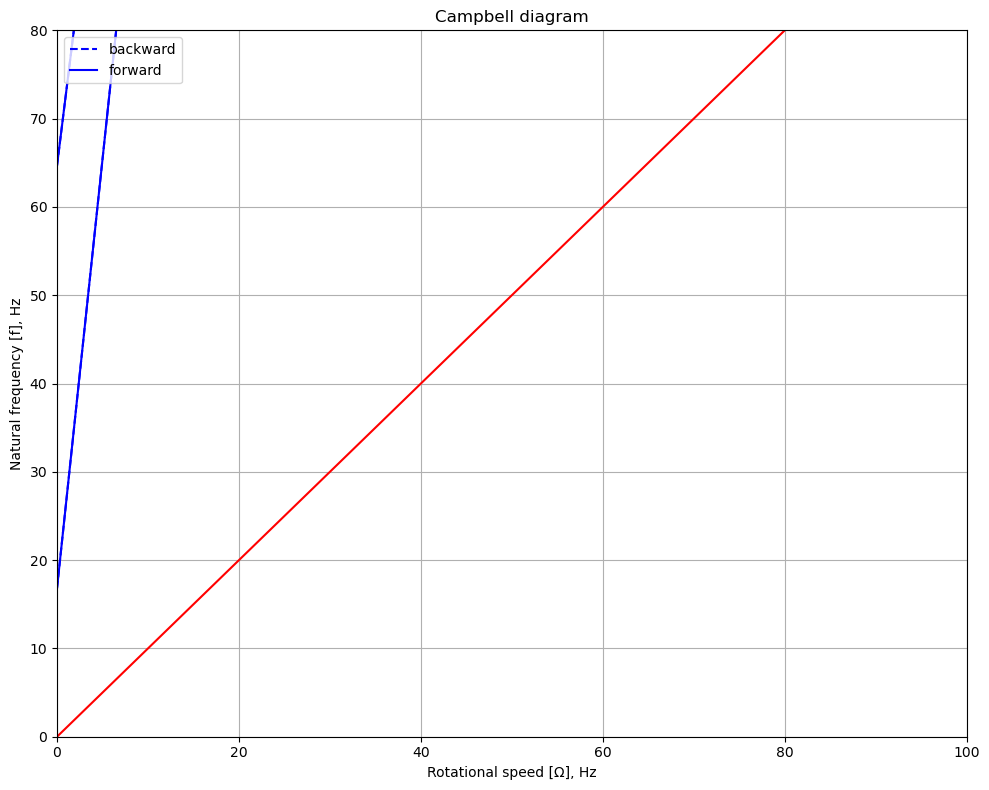

LeigOmega shape: (44, 11)
CAMP shape: (44, 11)
Number of speeds: 11
X points: 11
Unique f_n count: 22

Собственные частоты при Ω=0 (первые 2):
  f_n[0] = 16.813702594875224 Hz
  f_n[1] = 64.68011626927554 Hz
  f_n[2] = 171.9812397146843 Hz
  f_n[3] = 265.2927959664556 Hz


NameError: name 'pd' is not defined

In [31]:
# =============================================================================
# ФУНКЦИЯ POLYEIG
# Решает квадратичную задачу (K + λC + λ²M)x = 0
# через блочную линеризацию A z = λ B z:
# A = [[0, I], [-K, -C]], B = [[I, 0], [0, M]], z = [x, λx]
# =============================================================================
def polyeig(*A):
    if len(A) != 3:
        raise ValueError("Для квадратичной задачи передайте ровно 3 матрицы: K, C, M.")

    K, C, M = A

    if K.ndim != 2 or C.ndim != 2 or M.ndim != 2:
        raise ValueError("K, C, M должны быть двумерными матрицами.")
    if K.shape[0] != K.shape[1] or C.shape[0] != C.shape[1] or M.shape[0] != M.shape[1]:
        raise ValueError("K, C, M должны быть квадратными.")
    if not (K.shape == C.shape == M.shape):
        raise ValueError(
            f"Несогласованные размерности: K{K.shape}, C{C.shape}, M{M.shape}."
        )

    n = K.shape[0]

    cond_M = np.linalg.cond(M)
    if not np.isfinite(cond_M):
        raise np.linalg.LinAlgError("Матрица M вырождена: cond(M) не является конечным числом.")
    if cond_M > 1e12:
        raise np.linalg.LinAlgError(
            f"Матрица M плохо обусловлена (cond(M) = {cond_M:.3e}); решение может быть неустойчивым."
        )

    Z = np.zeros_like(M, dtype=np.complex128)
    I = np.eye(n, dtype=np.complex128)

    A_lin = np.block([
        [Z, I],
        [-K.astype(np.complex128), -C.astype(np.complex128)]
    ])
    B_lin = np.block([
        [I, Z],
        [Z, M.astype(np.complex128)]
    ])

    eigenvalues, eigenvectors = eig(A_lin, B_lin)
    mask = np.isfinite(eigenvalues)
    eigenvalues = eigenvalues[mask]
    eigenvectors = eigenvectors[:n, mask]

    return eigenvalues, eigenvectors
# =============================================================================
# ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ: УНИКАЛЬНЫЕ ЧАСТОТЫ (С ДОПУСКОМ)
#=============================================================================
def unique_with_tol(values, tol=1e-6):
    unique_vals = []
    unique_idx = []
    
    for idx, val in enumerate(values):
        if not any(np.isclose(val, u, atol=tol, rtol=0.0) for u in unique_vals):
            unique_vals.append(val)
            unique_idx.append(idx)
    
    return np.array(unique_vals), np.array(unique_idx, dtype=int)

# =============================================================================
# ПАРАМЕТРЫ
# =============================================================================
Omegastart = 2000    # RPM
Omegafinal = 22000   # RPM
Omegastep = 2000     # RPM

Omega_rad = np.arange((Omegastart * 2 * np.pi) / 60, 
                      ((Omegafinal + Omegastep) * 2 * np.pi) / 60, 
                      (Omegastep * 2 * np.pi) / 60)

n_speeds = len(Omega_rad)

# Оставляем только уникальные собственные частоты при Ω=0
freq_tol = 1e-6
f_n_unique, _ = unique_with_tol(np.asarray(freqs), tol=freq_tol)
f_n = f_n_unique

n_rows = 2 * len(f_n)  # т.к. прямая и обратная
n_cols = len(Omega_rad)

# Формирование матрицы LеigOmegа: строки - исходное решение задачи на собственные значения, столбцы - частота возбуждения, [рад/с]
LeigOmega = np.zeros((n_rows, n_cols), dtype=complex)
j_omega = 0

for Omega in Omega_rad:
    # Квадратичный полином: K + λC + λ²M = 0
    # Порядок аргументов polyeig: (K, C, M)
    Leig, _ = polyeig(Kf, D_b + Omega * G0, Mf)
    LeigOmega[:, j_omega] = Leig[:n_rows]
    j_omega += 1 

# =============================================================================
# ФОРМИРОВАНИЕ МАТРИЦЫ CAMP - строки - собственные частоты, [Гц], столбцы - частоты возбуждения, [рад/с]
# =============================================================================

camp_raw = np.abs(np.imag(LeigOmega[:, :j_omega]) / (2 * np.pi))
CAMP = np.zeros_like(camp_raw)
# Сортируем только стартовую колонку, затем трассируем ветви по близости между соседними скоростями.
# Это сохраняет соответствие мод при выводе >2 мод
start_order = np.argsort(camp_raw[:, 0])
CAMP[:, 0] = camp_raw[start_order, 0]
    
for col in range(1, j_omega):
    curr = camp_raw[:, col]
    available = set(range(n_rows))
    
    for row in range(n_rows):
        prev_value = CAMP[row, col - 1]
        best_idx = min(available, key=lambda idx: abs(curr[idx] - prev_value))
        CAMP[row, col] = camp_raw[best_idx, col]
        available.remove(best_idx)
# =============================================================================
# ПОСТРОЕНИЕ ДИАГРАММЫ КЭМПБЕЛЛА 
# =============================================================================
plt.figure(figsize=(10, 8))

X = Omega_rad / (2 * np.pi)
X_plot = np.concatenate(([0.0], X))

#Настройка отображаемых мод
n_modes_available = min(len(f_n), CAMP.shape[0] // 2)
n_modes_to_plot = min(4, n_modes_available)
mode_indices = np.arange(n_modes_to_plot)

for mode_idx in mode_indices:
    backward_row = 2 * mode_idx
    forward_row = backward_row + 1
    f_backward = np.concatenate(([f_n[mode_idx]], CAMP[backward_row, :]))
    f_forward = np.concatenate(([f_n[mode_idx]], CAMP[forward_row, :]))

    plt.plot(X_plot, f_backward, 'b--', linewidth=1.5)
    plt.plot(X_plot, f_forward, 'b-', linewidth=1.5)

# Диагональ
X_line = np.linspace(0, X_plot.max(), 200)
f2 = X_line
plt.plot(X_line, f2, 'r-', linewidth=1.5)

plt.xlim([0, 100])
plt.ylim([0, 80])

plt.grid(True)
plt.legend(['backward', 'forward'], loc='upper left')
plt.title('Campbell diagram')
plt.xlabel('Rotational speed [Ω], Hz')
plt.ylabel('Natural frequency [f], Hz')

plt.tight_layout()
plt.show()

# =============================================================================
# ВЫВОД ИНФО
# =============================================================================
print(f"LeigOmega shape: {LeigOmega.shape}")
print(f"CAMP shape: {CAMP.shape}")
print(f"Number of speeds: {n_speeds}")
print(f"X points: {len(X)}")
print(f"Unique f_n count: {len(f_n)}")

print(f"
Собственные частоты при Ω=0 (первые 2):")
for i in range(min(4, len(f_n))):
    print(f"  f_n[{i}] = {f_n[i]:} Hz")

pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)


print(pd.DataFrame(CAMP).head(20))
